In [130]:
import pandas as pd

# Load the raw data
df = pd.read_csv("Astram event data_anonymized - Astram event data_anonymizedb40ac87.csv", low_memory=False)

# 1. Total Rows and Columns
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}\n")

# 2. Exact Null Values per column
print("--- MISSING VALUES ---")
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

Total Rows: 8173
Total Columns: 46

--- MISSING VALUES ---
map_file                 8173
meta_data                8173
comment                  8173
direction                8130
resolved_at_longitude    8099
resolved_at_latitude     8099
resolved_at_address      8099
resolved_datetime        8099
resolved_by_id           8099
citizen_accident_id      8045
assigned_to_police_id    8045
route_path               8036
age_of_truck             7897
cargo_material           7897
reason_breakdown         7897
end_datetime             7683
end_address              7486
junction                 5663
closed_datetime          5032
closed_by_id             5032
gba_identifier           4729
zone                     4729
veh_no                   3287
veh_type                 3286
description              1360
kgid                      259
endlatitude               169
endlongitude              169
corridor                   20
address                     3
last_modified_by_id         3
created_by_

In [131]:
time_cols = ['start_datetime', 'resolved_datetime', 'end_datetime', 'closed_datetime']
for col in time_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df = df.dropna(subset=['start_datetime'])
best_end = df['resolved_datetime'].combine_first(df['end_datetime']).combine_first(df['closed_datetime'])
df['target_mins'] = (best_end - df['start_datetime']).dt.total_seconds() / 60



# 3. DROP COLUMNS (>4000 missing + useless IDs/text)
cols_to_drop = [
    # The > 4000 missing columns
    'meta_data', 'map_file', 'comment', 'direction',
    'resolved_at_longitude', 'resolved_at_latitude', 'resolved_at_address',
    'resolved_by_id', 'resolved_datetime', 'citizen_accident_id',
    'assigned_to_police_id', 'route_path', 'age_of_truck',
    'reason_breakdown', 'cargo_material', 'end_datetime',
    'end_address', 'junction', 'closed_by_id', 'closed_datetime',
    'gba_identifier', 'zone',
    # IDs and free-text that ML cannot use properly
    'id', 'origin_incident_number', 'veh_no', 'description',
    'kgid', 'created_by_id', 'last_modified_by_id', 'start_datetime'
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

# 4. FILL REMAINING NULLS
# A. Categoricals (Fill with Mode)
cat_cols = ['veh_type', 'corridor', 'priority', 'event_type', 'event_cause']
for col in cat_cols:
    if col in df.columns:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)

# B. Numerical & Coordinates (Fill with Median)
num_cols = ['latitude', 'longitude', 'endlatitude', 'endlongitude']
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

print(f"\nFinal Cleaned Dataset Shape: {df.shape}")
print("Remaining Missing Values in Dataset:")
print(df.isnull().sum().sum()) # Should be


Final Cleaned Dataset Shape: (8057, 18)
Remaining Missing Values in Dataset:
4512


In [132]:
df

,event_type,latitude,longitude,endlatitude,endlongitude,address,event_cause,requires_road_closure,status,authenticated,modified_datetime,veh_type,corridor,priority,created_date,client_id,police_station,target_mins
0,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",vehicle_breakdown,False,closed,yes,2024-03-07 19:35:47.871698+00,lcv,Tumkur Road,High,2024-03-07 17:03:51.164032+00,1,Peenya,NaN
1,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",vehicle_breakdown,False,resolved,yes,2024-01-30 04:17:46.828979+00,heavy_vehicle,ORR East 1,High,2024-01-30 04:08:22.954979+00,1,HSR Layout,10.377589
2,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",others,False,closed,yes,2024-01-30 04:56:03.282003+00,bmtc_bus,Non-corridor,Low,2023-11-11 06:20:00.989398+00,1,Wilson Garden,115117.998975
3,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...",tree_fall,True,closed,yes,2024-03-14 07:42:05.55005+00,bmtc_bus,Non-corridor,Low,2024-03-07 17:58:56.696892+00,1,Sadashivanagar,9465.174807
4,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",vehicle_breakdown,False,closed,yes,2024-01-30 05:35:17.33908+00,private_bus,Non-corridor,Low,2024-01-30 04:58:55.937662+00,1,Wilson Garden,38.749838
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8168,unplanned,12.917775,77.600024,0.000000,0.000000,"Jayadeva BTM Underpass, Jayadeva Junction, BTM...",vehicle_breakdown,False,closed,yes,2024-01-29 21:32:37.883912+00,lcv,Bannerghata Road,High,2024-01-29 21:12:45.730967+00,1,Mico Layout,21.635088
8169,unplanned,12.890951,77.564757,0.000000,0.000000,"Konanakunte Main Road, Century Central, Naidu ...",vehicle_breakdown,False,closed,yes,2024-01-29 22:03:41.31391+00,bmtc_bus,Non-corridor,Low,2024-01-29 21:54:18.516483+00,1,K.S. Layout,13.002654
8170,unplanned,12.916976,77.583443,0.000000,0.000000,"46th Cross Road, Adarsh Palace Apartment, TMC ...",vehicle_breakdown,False,closed,no,2024-01-29 22:11:51.763262+00,bmtc_bus,Non-corridor,Low,2024-01-29 21:58:16.565954+00,1,Jayanagara,15.776179
8171,unplanned,12.972042,77.619483,0.000000,0.000000,"Trinity Church Road, Trinity Circle, Ashok Nag...",pot_holes,False,active,yes,2024-01-29 22:57:48.11619+00,bmtc_bus,Old Madras Road,High,2024-01-29 22:55:35.048536+00,1,Halasur,NaN


In [133]:
df.isnull().sum()
df["target_mins"]

,target_mins
0,NaN
1,10.377589
2,115117.998975
3,9465.174807
4,38.749838
...,...
8168,21.635088
8169,13.002654
8170,15.776179
8171,NaN


In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8057 entries, 0 to 8172
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   event_type             8057 non-null   object 
 1   latitude               8057 non-null   float64
 2   longitude              8057 non-null   float64
 3   endlatitude            8057 non-null   float64
 4   endlongitude           8057 non-null   float64
 5   address                8054 non-null   object 
 6   event_cause            8057 non-null   object 
 7   requires_road_closure  8057 non-null   bool   
 8   status                 8057 non-null   object 
 9   authenticated          8057 non-null   object 
 10  modified_datetime      8057 non-null   object 
 11  veh_type               8057 non-null   object 
 12  corridor               8057 non-null   object 
 13  priority               8057 non-null   object 
 14  created_date           8057 non-null   object 
 15  client_id

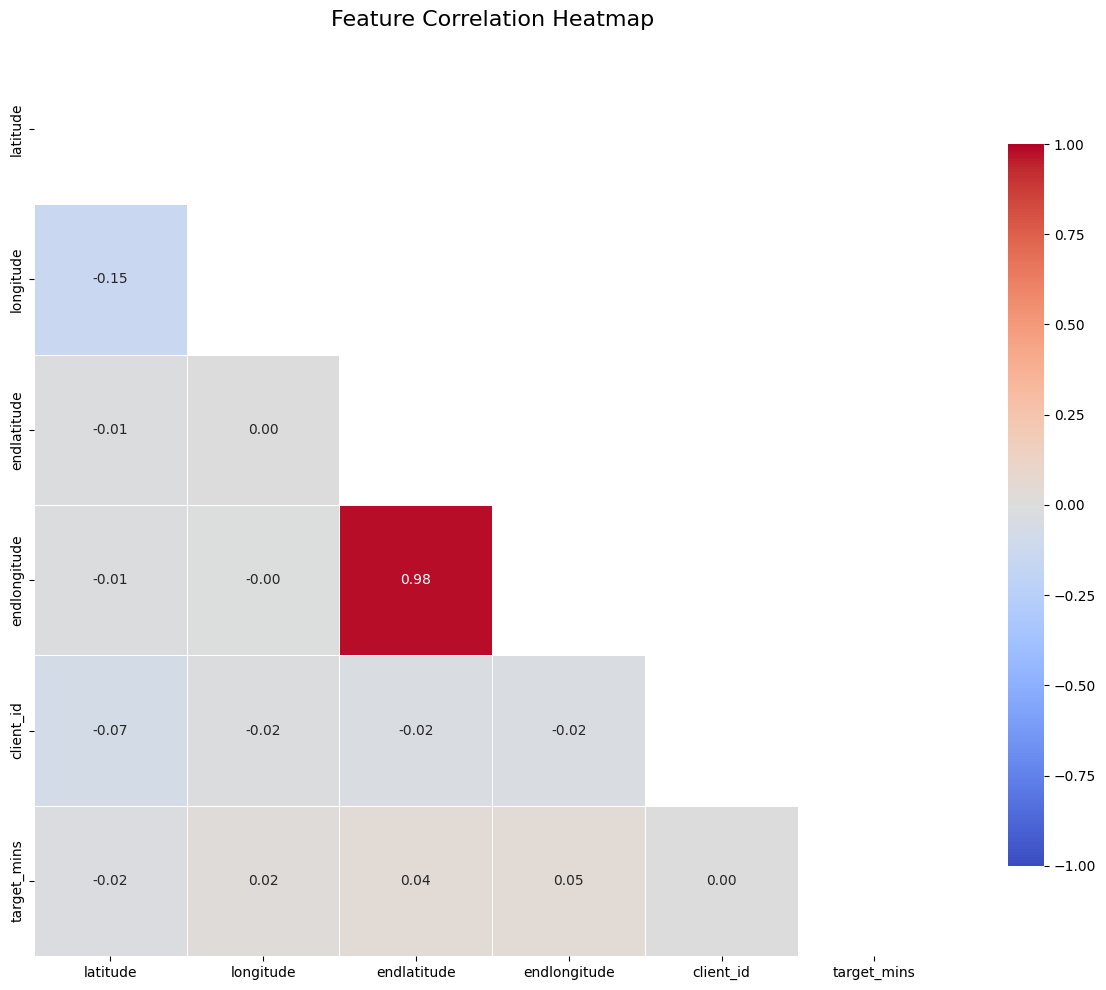


--- Correlation with Target Variable (target_mins) ---
target_mins     1.000000
endlongitude    0.046727
endlatitude     0.043545
longitude       0.023354
client_id       0.001398
latitude       -0.022926
Name: target_mins, dtype: float64


In [135]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
numeric_df = df.select_dtypes(include=['float64', 'int32', 'int64'])

# 2. Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# 3. Set up the visual canvas
plt.figure(figsize=(12, 10))
plt.title("Feature Correlation Heatmap", fontsize=16, pad=20)

# 4. Create a mask to hide the top right triangle (it's a mirror image of the bottom left)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 5. Plot the heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,          # Show the actual correlation numbers
    fmt=".2f",           # Round to 2 decimal places
    cmap="coolwarm",     # Blue for negative correlation, Red for positive
    vmin=-1, vmax=1,     # Set the scale from -1 to 1
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.tight_layout()
plt.show()

# Print the specific correlations targeting our goal (target_mins)
print("\n--- Correlation with Target Variable (target_mins) ---")
print(corr_matrix['target_mins'].sort_values(ascending=False))

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [137]:
# Select only the text/categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

# Loop through each column and print the unique value counts
for col in cat_cols:
    print(f"\n{'='*30}")
    print(f"COLUMN: {col.upper()}")
    print(f"{'='*30}")
    print(df[col].value_counts())
    print(f"Total Unique Categories: {df[col].nunique()}\n")


COLUMN: EVENT_TYPE
event_type
unplanned    7692
planned       365
Name: count, dtype: int64
Total Unique Categories: 2


COLUMN: ADDRESS
address
Outer Ring Road, Karthik Nagar, Marathahalli, Bengaluru, Karnataka. Pin-560037 (India)                     85
2nd Cross Road, MTB Area, Jayanagar, Bengaluru, Karnataka. Pin-560041 (India)                              44
Sankey Road, RV Layout, Seshadripuram, Bengaluru, Karnataka. Pin-560020 (India)                            36
MBT Road, Block 5 Stage 1, HBR Layout, Bengaluru, Karnataka. Pin-560043 (India)                            35
Sankey Road, MD Nanjundaswamy Circle, Rajamahal Guttahalli, Bengaluru, Karnataka. Pin-560003 (India)       34
                                                                                                           ..
BTS Main Road, NGO Colony, Wilson Garden, Bengaluru, Karnataka. Pin-560027 (India)                          1
1st Cross Road, Rashtrakavi Kuvempu Nagar, BTM Layout Stage 2, Bengaluru, Karnataka.

In [138]:
import pandas as pd
import numpy as np

# 1. PARSE THE ADDRESS
# Split the address by commas into a list
address_parts = df['address'].astype(str).str.split(',')

# Safely extract the 2nd item (index 1) for add1, and 3rd item (index 2) for add2
df['add1'] = address_parts.apply(lambda x: x[1].strip() if isinstance(x, list) and len(x) > 1 else "Unknown")
df['add2'] = address_parts.apply(lambda x: x[2].strip() if isinstance(x, list) and len(x) > 2 else "Unknown")

# Use Regex to extract the 6 digits immediately following "Pin-"
df['pin'] = df['address'].astype(str).str.extract(r'Pin-(\d{6})')
df['pin'] = df['pin'].fillna("Unknown")


# 2. PARSE CREATED & MODIFIED DATETIMES
time_columns = {
    'created_date': 'c',
    'modified_datetime': 'm'
}

for col, prefix in time_columns.items():
    if col in df.columns:
        # Convert to proper datetime objects
        dt_series = pd.to_datetime(df[col], errors='coerce')

        # Extract individual components
        df[f'{prefix}month'] = dt_series.dt.month.fillna(0).astype(int)
        df[f'{prefix}date'] = dt_series.dt.day.fillna(0).astype(int)
        df[f'{prefix}hour'] = dt_series.dt.hour.fillna(0).astype(int)
        df[f'{prefix}time'] = dt_series.dt.strftime('%H:%M').fillna("Unknown")


# 3. DROP THE ORIGINAL COLUMNS
cols_to_drop = ['address', 'created_date', 'modified_datetime']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

# Check the new columns
print(df[['add1', 'add2', 'pin', 'cmonth', 'cdate', 'chour', 'ctime']].head())

                              add1             add2     pin  cmonth  cdate  \
0         Jalahalli Cross Junction           Peenya  560058       3      7   
1                   Heavie Halcyon            Agara  560102       1     30   
2  Dr Sri Shantaveera Swami Circle          Mavalli  560004      11     11   
3                   Bashyam Circle  Sadashiva Nagar  560080       3      7   
4       Lalbagh Main Gate Junction    Wilson Garden  560027       1     30   

   chour  ctime  
0     17  17:03  
1      4  04:08  
2      6  06:20  
3     17  17:58  
4      4  04:58  


In [139]:
df.columns

Index(['event_type', 'latitude', 'longitude', 'endlatitude', 'endlongitude',
       'event_cause', 'requires_road_closure', 'status', 'authenticated',
       'veh_type', 'corridor', 'priority', 'client_id', 'police_station',
       'target_mins', 'add1', 'add2', 'pin', 'cmonth', 'cdate', 'chour',
       'ctime', 'mmonth', 'mdate', 'mhour', 'mtime'],
      dtype='object')

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8057 entries, 0 to 8172
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   event_type             8057 non-null   object 
 1   latitude               8057 non-null   float64
 2   longitude              8057 non-null   float64
 3   endlatitude            8057 non-null   float64
 4   endlongitude           8057 non-null   float64
 5   event_cause            8057 non-null   object 
 6   requires_road_closure  8057 non-null   bool   
 7   status                 8057 non-null   object 
 8   authenticated          8057 non-null   object 
 9   veh_type               8057 non-null   object 
 10  corridor               8057 non-null   object 
 11  priority               8057 non-null   object 
 12  client_id              8057 non-null   int64  
 13  police_station         8057 non-null   object 
 14  target_mins            3548 non-null   float64
 15  add1     

In [141]:
df

,event_type,latitude,longitude,endlatitude,endlongitude,event_cause,requires_road_closure,status,authenticated,veh_type,...,add2,pin,cmonth,cdate,chour,ctime,mmonth,mdate,mhour,mtime
0,unplanned,13.040004,77.518099,0.000000,0.000000,vehicle_breakdown,False,closed,yes,lcv,...,Peenya,560058,3,7,17,17:03,3,7,19,19:35
1,unplanned,12.921876,77.645158,0.000000,0.000000,vehicle_breakdown,False,resolved,yes,heavy_vehicle,...,Agara,560102,1,30,4,04:08,1,30,4,04:17
2,unplanned,12.955622,77.585708,0.000000,0.000000,others,False,closed,yes,bmtc_bus,...,Mavalli,560004,11,11,6,06:20,1,30,4,04:56
3,unplanned,13.006147,77.579435,13.006239,77.579516,tree_fall,True,closed,yes,bmtc_bus,...,Sadashiva Nagar,560080,3,7,17,17:58,3,14,7,07:42
4,unplanned,12.953980,77.585233,0.000000,0.000000,vehicle_breakdown,False,closed,yes,private_bus,...,Wilson Garden,560027,1,30,4,04:58,1,30,5,05:35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8168,unplanned,12.917775,77.600024,0.000000,0.000000,vehicle_breakdown,False,closed,yes,lcv,...,BTM Layout Stage 1,560029,1,29,21,21:12,1,29,21,21:32
8169,unplanned,12.890951,77.564757,0.000000,0.000000,vehicle_breakdown,False,closed,yes,bmtc_bus,...,Naidu Layout,560062,1,29,21,21:54,1,29,22,22:03
8170,unplanned,12.916976,77.583443,0.000000,0.000000,vehicle_breakdown,False,closed,no,bmtc_bus,...,TMC Layout,560078,1,29,21,21:58,1,29,22,22:11
8171,unplanned,12.972042,77.619483,0.000000,0.000000,pot_holes,False,active,yes,bmtc_bus,...,Ashok Nagar,560001,1,29,22,22:55,1,29,22,22:57


In [142]:
df_clean = df.copy()

In [143]:
df_clean

,event_type,latitude,longitude,endlatitude,endlongitude,event_cause,requires_road_closure,status,authenticated,veh_type,...,add2,pin,cmonth,cdate,chour,ctime,mmonth,mdate,mhour,mtime
0,unplanned,13.040004,77.518099,0.000000,0.000000,vehicle_breakdown,False,closed,yes,lcv,...,Peenya,560058,3,7,17,17:03,3,7,19,19:35
1,unplanned,12.921876,77.645158,0.000000,0.000000,vehicle_breakdown,False,resolved,yes,heavy_vehicle,...,Agara,560102,1,30,4,04:08,1,30,4,04:17
2,unplanned,12.955622,77.585708,0.000000,0.000000,others,False,closed,yes,bmtc_bus,...,Mavalli,560004,11,11,6,06:20,1,30,4,04:56
3,unplanned,13.006147,77.579435,13.006239,77.579516,tree_fall,True,closed,yes,bmtc_bus,...,Sadashiva Nagar,560080,3,7,17,17:58,3,14,7,07:42
4,unplanned,12.953980,77.585233,0.000000,0.000000,vehicle_breakdown,False,closed,yes,private_bus,...,Wilson Garden,560027,1,30,4,04:58,1,30,5,05:35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8168,unplanned,12.917775,77.600024,0.000000,0.000000,vehicle_breakdown,False,closed,yes,lcv,...,BTM Layout Stage 1,560029,1,29,21,21:12,1,29,21,21:32
8169,unplanned,12.890951,77.564757,0.000000,0.000000,vehicle_breakdown,False,closed,yes,bmtc_bus,...,Naidu Layout,560062,1,29,21,21:54,1,29,22,22:03
8170,unplanned,12.916976,77.583443,0.000000,0.000000,vehicle_breakdown,False,closed,no,bmtc_bus,...,TMC Layout,560078,1,29,21,21:58,1,29,22,22:11
8171,unplanned,12.972042,77.619483,0.000000,0.000000,pot_holes,False,active,yes,bmtc_bus,...,Ashok Nagar,560001,1,29,22,22:55,1,29,22,22:57


In [144]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8057 entries, 0 to 8172
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   event_type             8057 non-null   object 
 1   latitude               8057 non-null   float64
 2   longitude              8057 non-null   float64
 3   endlatitude            8057 non-null   float64
 4   endlongitude           8057 non-null   float64
 5   event_cause            8057 non-null   object 
 6   requires_road_closure  8057 non-null   bool   
 7   status                 8057 non-null   object 
 8   authenticated          8057 non-null   object 
 9   veh_type               8057 non-null   object 
 10  corridor               8057 non-null   object 
 11  priority               8057 non-null   object 
 12  client_id              8057 non-null   int64  
 13  police_station         8057 non-null   object 
 14  target_mins            3548 non-null   float64
 15  add1     

In [145]:
# The "Better" (and mathematically required) Way:
temp_created = pd.to_datetime("2024-" + df_clean['cmonth'].astype(str) + "-" + df_clean['cdate'].astype(str) + " " + df_clean['ctime'])
temp_modified = pd.to_datetime("2024-" + df_clean['mmonth'].astype(str) + "-" + df_clean['mdate'].astype(str) + " " + df_clean['mtime'])

df_clean['min_to_take_action'] = (temp_modified - temp_created).dt.total_seconds() / 60

In [146]:
df_clean


,event_type,latitude,longitude,endlatitude,endlongitude,event_cause,requires_road_closure,status,authenticated,veh_type,...,pin,cmonth,cdate,chour,ctime,mmonth,mdate,mhour,mtime,min_to_take_action
0,unplanned,13.040004,77.518099,0.000000,0.000000,vehicle_breakdown,False,closed,yes,lcv,...,560058,3,7,17,17:03,3,7,19,19:35,152.0
1,unplanned,12.921876,77.645158,0.000000,0.000000,vehicle_breakdown,False,resolved,yes,heavy_vehicle,...,560102,1,30,4,04:08,1,30,4,04:17,9.0
2,unplanned,12.955622,77.585708,0.000000,0.000000,others,False,closed,yes,bmtc_bus,...,560004,11,11,6,06:20,1,30,4,04:56,-411924.0
3,unplanned,13.006147,77.579435,13.006239,77.579516,tree_fall,True,closed,yes,bmtc_bus,...,560080,3,7,17,17:58,3,14,7,07:42,9464.0
4,unplanned,12.953980,77.585233,0.000000,0.000000,vehicle_breakdown,False,closed,yes,private_bus,...,560027,1,30,4,04:58,1,30,5,05:35,37.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8168,unplanned,12.917775,77.600024,0.000000,0.000000,vehicle_breakdown,False,closed,yes,lcv,...,560029,1,29,21,21:12,1,29,21,21:32,20.0
8169,unplanned,12.890951,77.564757,0.000000,0.000000,vehicle_breakdown,False,closed,yes,bmtc_bus,...,560062,1,29,21,21:54,1,29,22,22:03,9.0
8170,unplanned,12.916976,77.583443,0.000000,0.000000,vehicle_breakdown,False,closed,no,bmtc_bus,...,560078,1,29,21,21:58,1,29,22,22:11,13.0
8171,unplanned,12.972042,77.619483,0.000000,0.000000,pot_holes,False,active,yes,bmtc_bus,...,560001,1,29,22,22:55,1,29,22,22:57,2.0


In [147]:
# 1. The Reality Filter: Drop time-travel, bots, and forgotten tickets
df_clean = df_clean[
    (df_clean['min_to_take_action'] > 1) &
    (df_clean['min_to_take_action'] <= 1440)
]

# 2. Drop any rows where the math completely failed (NaNs)
df_clean = df_clean.dropna(subset=['min_to_take_action'])

# 3. Let's see the new, clean distribution!
print(f"Clean rows remaining for ML: {len(df_clean)}")
print("\n--- Final Response Time Distribution (Minutes) ---")
print(df_clean['min_to_take_action'].describe())

Clean rows remaining for ML: 6993

--- Final Response Time Distribution (Minutes) ---
count    6993.000000
mean      122.065351
std       161.833649
min         2.000000
25%        32.000000
50%       120.000000
75%       151.000000
max      1440.000000
Name: min_to_take_action, dtype: float64


In [148]:
df_clean

,event_type,latitude,longitude,endlatitude,endlongitude,event_cause,requires_road_closure,status,authenticated,veh_type,...,pin,cmonth,cdate,chour,ctime,mmonth,mdate,mhour,mtime,min_to_take_action
0,unplanned,13.040004,77.518099,0.000000,0.000000,vehicle_breakdown,False,closed,yes,lcv,...,560058,3,7,17,17:03,3,7,19,19:35,152.0
1,unplanned,12.921876,77.645158,0.000000,0.000000,vehicle_breakdown,False,resolved,yes,heavy_vehicle,...,560102,1,30,4,04:08,1,30,4,04:17,9.0
4,unplanned,12.953980,77.585233,0.000000,0.000000,vehicle_breakdown,False,closed,yes,private_bus,...,560027,1,30,4,04:58,1,30,5,05:35,37.0
5,unplanned,13.066485,77.599875,0.000000,0.000000,accident,False,closed,yes,bmtc_bus,...,Unknown,11,28,3,03:08,11,28,4,04:35,87.0
6,unplanned,12.932870,77.487981,0.000000,0.000000,vehicle_breakdown,False,closed,yes,bmtc_bus,...,560060,1,30,7,07:28,1,30,9,09:35,127.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8168,unplanned,12.917775,77.600024,0.000000,0.000000,vehicle_breakdown,False,closed,yes,lcv,...,560029,1,29,21,21:12,1,29,21,21:32,20.0
8169,unplanned,12.890951,77.564757,0.000000,0.000000,vehicle_breakdown,False,closed,yes,bmtc_bus,...,560062,1,29,21,21:54,1,29,22,22:03,9.0
8170,unplanned,12.916976,77.583443,0.000000,0.000000,vehicle_breakdown,False,closed,no,bmtc_bus,...,560078,1,29,21,21:58,1,29,22,22:11,13.0
8171,unplanned,12.972042,77.619483,0.000000,0.000000,pot_holes,False,active,yes,bmtc_bus,...,560001,1,29,22,22:55,1,29,22,22:57,2.0


In [149]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6993 entries, 0 to 8172
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   event_type             6993 non-null   object 
 1   latitude               6993 non-null   float64
 2   longitude              6993 non-null   float64
 3   endlatitude            6993 non-null   float64
 4   endlongitude           6993 non-null   float64
 5   event_cause            6993 non-null   object 
 6   requires_road_closure  6993 non-null   bool   
 7   status                 6993 non-null   object 
 8   authenticated          6993 non-null   object 
 9   veh_type               6993 non-null   object 
 10  corridor               6993 non-null   object 
 11  priority               6993 non-null   object 
 12  client_id              6993 non-null   int64  
 13  police_station         6993 non-null   object 
 14  target_mins            2763 non-null   float64
 15  add1     

In [150]:
# Drop the old broken target column
df_clean = df_clean.drop(columns=['target_mins'], errors='ignore')

# Verify it is officially gone
print("Target dropped! Remaining columns:")
print(df_clean.columns.tolist())

Target dropped! Remaining columns:
['event_type', 'latitude', 'longitude', 'endlatitude', 'endlongitude', 'event_cause', 'requires_road_closure', 'status', 'authenticated', 'veh_type', 'corridor', 'priority', 'client_id', 'police_station', 'add1', 'add2', 'pin', 'cmonth', 'cdate', 'chour', 'ctime', 'mmonth', 'mdate', 'mhour', 'mtime', 'min_to_take_action']


In [151]:
df_pure=df_clean.copy()

In [152]:
df_pure

,event_type,latitude,longitude,endlatitude,endlongitude,event_cause,requires_road_closure,status,authenticated,veh_type,...,pin,cmonth,cdate,chour,ctime,mmonth,mdate,mhour,mtime,min_to_take_action
0,unplanned,13.040004,77.518099,0.000000,0.000000,vehicle_breakdown,False,closed,yes,lcv,...,560058,3,7,17,17:03,3,7,19,19:35,152.0
1,unplanned,12.921876,77.645158,0.000000,0.000000,vehicle_breakdown,False,resolved,yes,heavy_vehicle,...,560102,1,30,4,04:08,1,30,4,04:17,9.0
4,unplanned,12.953980,77.585233,0.000000,0.000000,vehicle_breakdown,False,closed,yes,private_bus,...,560027,1,30,4,04:58,1,30,5,05:35,37.0
5,unplanned,13.066485,77.599875,0.000000,0.000000,accident,False,closed,yes,bmtc_bus,...,Unknown,11,28,3,03:08,11,28,4,04:35,87.0
6,unplanned,12.932870,77.487981,0.000000,0.000000,vehicle_breakdown,False,closed,yes,bmtc_bus,...,560060,1,30,7,07:28,1,30,9,09:35,127.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8168,unplanned,12.917775,77.600024,0.000000,0.000000,vehicle_breakdown,False,closed,yes,lcv,...,560029,1,29,21,21:12,1,29,21,21:32,20.0
8169,unplanned,12.890951,77.564757,0.000000,0.000000,vehicle_breakdown,False,closed,yes,bmtc_bus,...,560062,1,29,21,21:54,1,29,22,22:03,9.0
8170,unplanned,12.916976,77.583443,0.000000,0.000000,vehicle_breakdown,False,closed,no,bmtc_bus,...,560078,1,29,21,21:58,1,29,22,22:11,13.0
8171,unplanned,12.972042,77.619483,0.000000,0.000000,pot_holes,False,active,yes,bmtc_bus,...,560001,1,29,22,22:55,1,29,22,22:57,2.0


In [153]:
df.head()

,event_type,latitude,longitude,endlatitude,endlongitude,event_cause,requires_road_closure,status,authenticated,veh_type,...,add2,pin,cmonth,cdate,chour,ctime,mmonth,mdate,mhour,mtime
0,unplanned,13.040004,77.518099,0.000000,0.000000,vehicle_breakdown,False,closed,yes,lcv,...,Peenya,560058,3,7,17,17:03,3,7,19,19:35
1,unplanned,12.921876,77.645158,0.000000,0.000000,vehicle_breakdown,False,resolved,yes,heavy_vehicle,...,Agara,560102,1,30,4,04:08,1,30,4,04:17
2,unplanned,12.955622,77.585708,0.000000,0.000000,others,False,closed,yes,bmtc_bus,...,Mavalli,560004,11,11,6,06:20,1,30,4,04:56
3,unplanned,13.006147,77.579435,13.006239,77.579516,tree_fall,True,closed,yes,bmtc_bus,...,Sadashiva Nagar,560080,3,7,17,17:58,3,14,7,07:42
4,unplanned,12.953980,77.585233,0.000000,0.000000,vehicle_breakdown,False,closed,yes,private_bus,...,Wilson Garden,560027,1,30,4,04:58,1,30,5,05:35


In [154]:
print(df_pure.iloc[0])

event_type                              unplanned
latitude                                13.040004
longitude                               77.518099
endlatitude                                   0.0
endlongitude                                  0.0
event_cause                     vehicle_breakdown
requires_road_closure                       False
status                                     closed
authenticated                                 yes
veh_type                                      lcv
corridor                              Tumkur Road
priority                                     High
client_id                                       1
police_station                             Peenya
add1                     Jalahalli Cross Junction
add2                                       Peenya
pin                                        560058
cmonth                                          3
cdate                                           7
chour                                          17


In [155]:
cat_cols = df_pure.select_dtypes(include=['float64', 'int32', 'int64']).columns

# Loop through each column and print the unique value counts
for col in cat_cols:
    print(f"\n{'='*30}")
    print(f"COLUMN: {col.upper()}")
    print(f"{'='*30}")
    print(df_pure[col].value_counts())
    print(f"Total Unique Categories: {df_pure[col].nunique()}\n")


COLUMN: LATITUDE
latitude
12.918617    52
12.931200     8
13.026353     5
13.026400     4
12.974930     4
             ..
12.921843     1
12.993789     1
12.905970     1
12.918205     1
13.097985     1
Name: count, Length: 6869, dtype: int64
Total Unique Categories: 6869


COLUMN: LONGITUDE
longitude
77.589460    52
77.686895     8
77.583971     6
77.544093     5
77.570277     4
             ..
77.631037     1
77.600409     1
77.641566     1
77.586062     1
77.626108     1
Name: count, Length: 6852, dtype: int64
Total Unique Categories: 6852


COLUMN: ENDLATITUDE
endlatitude
0.000000     6503
13.039457       2
12.997762       1
13.060086       1
12.961862       1
             ... 
13.048922       1
12.984686       1
12.982917       1
12.964122       1
12.921147       1
Name: count, Length: 490, dtype: int64
Total Unique Categories: 490


COLUMN: ENDLONGITUDE
endlongitude
0.000000     6503
77.573609       1
77.606635       1
77.736132       1
77.615306       1
             ... 
77.4968

In [156]:
# 1. The Final Hit List
stubborn_ghosts = ['endlatitude', 'endlongitude', 'client_id']

# 2. Hard Drop
df_pure = df_pure.drop(columns=[c for c in stubborn_ghosts if c in df_pure.columns], errors='ignore')

# 3. Verify the drop was successful
print("🚨 Final columns remaining:")
print(df_pure.columns.tolist())

🚨 Final columns remaining:
['event_type', 'latitude', 'longitude', 'event_cause', 'requires_road_closure', 'status', 'authenticated', 'veh_type', 'corridor', 'priority', 'police_station', 'add1', 'add2', 'pin', 'cmonth', 'cdate', 'chour', 'ctime', 'mmonth', 'mdate', 'mhour', 'mtime', 'min_to_take_action']


In [157]:
df_pure

,event_type,latitude,longitude,event_cause,requires_road_closure,status,authenticated,veh_type,corridor,priority,...,pin,cmonth,cdate,chour,ctime,mmonth,mdate,mhour,mtime,min_to_take_action
0,unplanned,13.040004,77.518099,vehicle_breakdown,False,closed,yes,lcv,Tumkur Road,High,...,560058,3,7,17,17:03,3,7,19,19:35,152.0
1,unplanned,12.921876,77.645158,vehicle_breakdown,False,resolved,yes,heavy_vehicle,ORR East 1,High,...,560102,1,30,4,04:08,1,30,4,04:17,9.0
4,unplanned,12.953980,77.585233,vehicle_breakdown,False,closed,yes,private_bus,Non-corridor,Low,...,560027,1,30,4,04:58,1,30,5,05:35,37.0
5,unplanned,13.066485,77.599875,accident,False,closed,yes,bmtc_bus,Non-corridor,Low,...,Unknown,11,28,3,03:08,11,28,4,04:35,87.0
6,unplanned,12.932870,77.487981,vehicle_breakdown,False,closed,yes,bmtc_bus,Non-corridor,Low,...,560060,1,30,7,07:28,1,30,9,09:35,127.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8168,unplanned,12.917775,77.600024,vehicle_breakdown,False,closed,yes,lcv,Bannerghata Road,High,...,560029,1,29,21,21:12,1,29,21,21:32,20.0
8169,unplanned,12.890951,77.564757,vehicle_breakdown,False,closed,yes,bmtc_bus,Non-corridor,Low,...,560062,1,29,21,21:54,1,29,22,22:03,9.0
8170,unplanned,12.916976,77.583443,vehicle_breakdown,False,closed,no,bmtc_bus,Non-corridor,Low,...,560078,1,29,21,21:58,1,29,22,22:11,13.0
8171,unplanned,12.972042,77.619483,pot_holes,False,active,yes,bmtc_bus,Old Madras Road,High,...,560001,1,29,22,22:55,1,29,22,22:57,2.0


In [158]:
df_pure.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6993 entries, 0 to 8172
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   event_type             6993 non-null   object 
 1   latitude               6993 non-null   float64
 2   longitude              6993 non-null   float64
 3   event_cause            6993 non-null   object 
 4   requires_road_closure  6993 non-null   bool   
 5   status                 6993 non-null   object 
 6   authenticated          6993 non-null   object 
 7   veh_type               6993 non-null   object 
 8   corridor               6993 non-null   object 
 9   priority               6993 non-null   object 
 10  police_station         6993 non-null   object 
 11  add1                   6993 non-null   object 
 12  add2                   6993 non-null   object 
 13  pin                    6993 non-null   object 
 14  cmonth                 6993 non-null   int64  
 15  cdate    

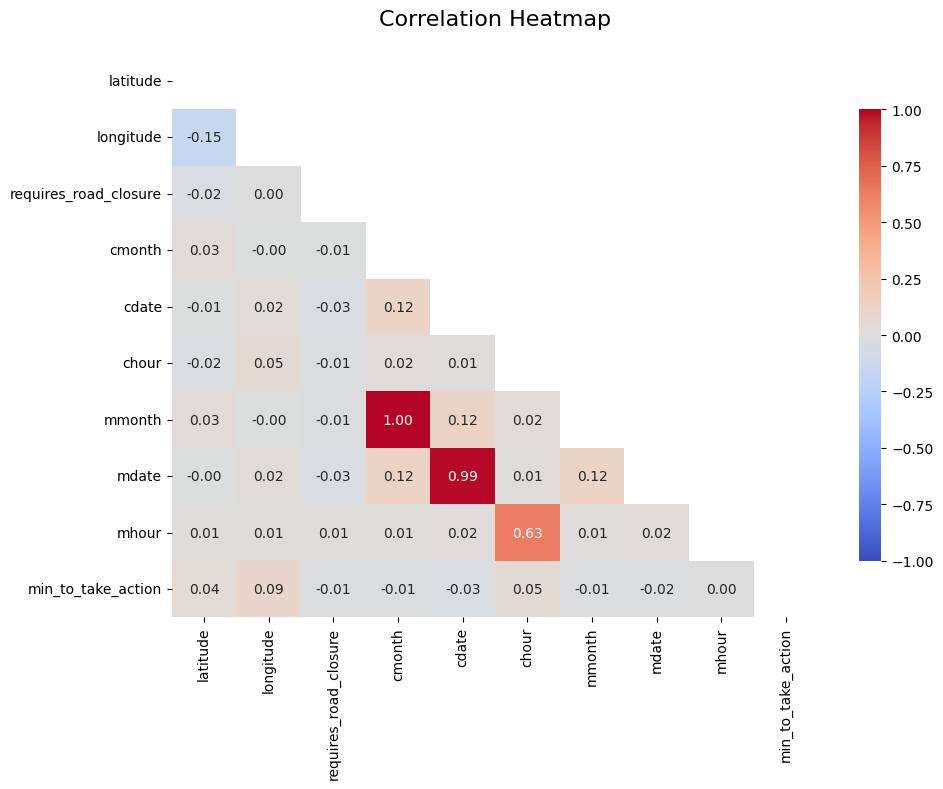

/tmp/ipykernel_2641/947085211.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pure, x=cat, y='min_to_take_action', ax=axes[i], showfliers=False, palette='Set2')
/tmp/ipykernel_2641/947085211.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pure, x=cat, y='min_to_take_action', ax=axes[i], showfliers=False, palette='Set2')
/tmp/ipykernel_2641/947085211.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pure, x=cat, y='min_to_take_action', ax=axes[i], showfliers=False, palette='Set2')
/tmp/ipykernel_2641/94708

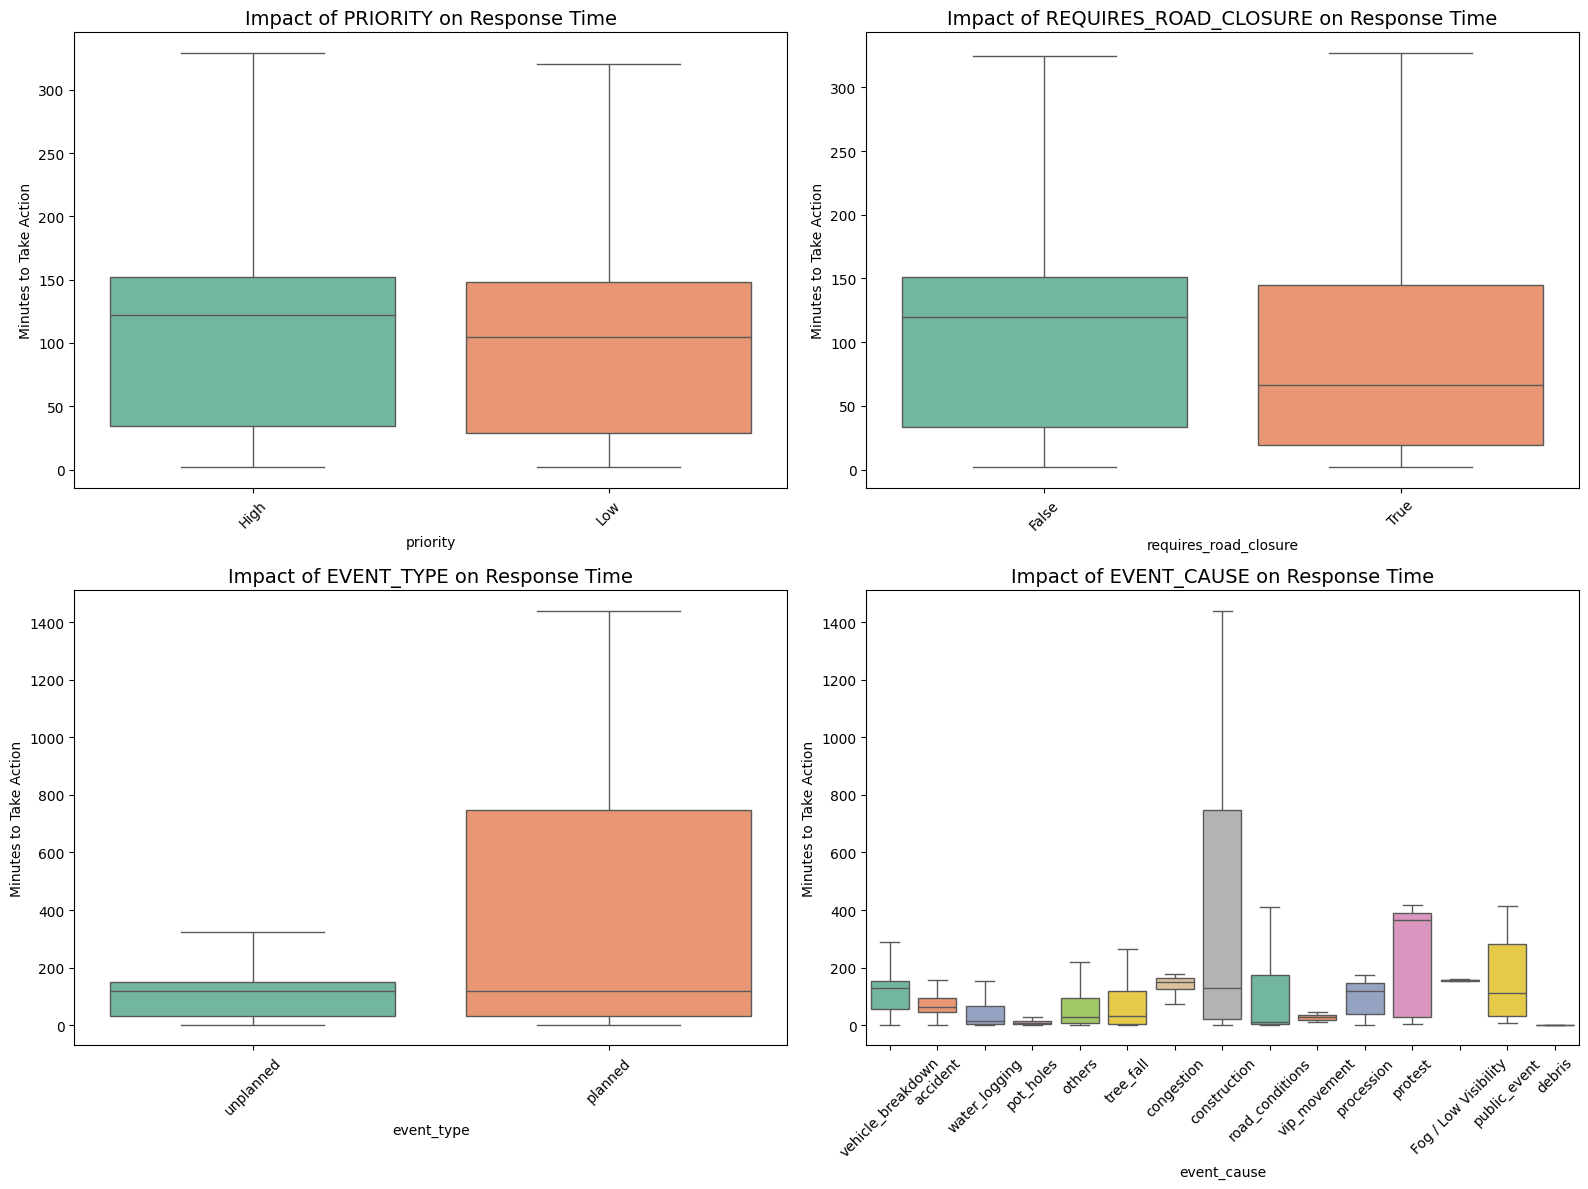

In [159]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. NUMERICAL CORRELATION HEATMAP ---
plt.figure(figsize=(10, 8))

# Select only numeric columns (Coordinates, Time components, Target)
numeric_df = df_pure.select_dtypes(include=['float64', 'int64', 'int32', 'bool'])
corr_matrix = numeric_df.corr()

# Generate the heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, cbar_kws={"shrink": .8}
)
plt.title("Correlation Heatmap", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# --- 2. CATEGORICAL BOX PLOTS ---
# Let's look at how these 4 specific categories impact the response time
categories_to_check = ['priority', 'requires_road_closure', 'event_type', 'event_cause']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, cat in enumerate(categories_to_check):
    if cat in df_pure.columns:
        # We use showfliers=False to hide extreme outliers so the box itself is visible
        sns.boxplot(data=df_pure, x=cat, y='min_to_take_action', ax=axes[i], showfliers=False, palette='Set2')
        axes[i].set_title(f"Impact of {cat.upper()} on Response Time", fontsize=14)
        axes[i].set_ylabel("Minutes to Take Action")
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

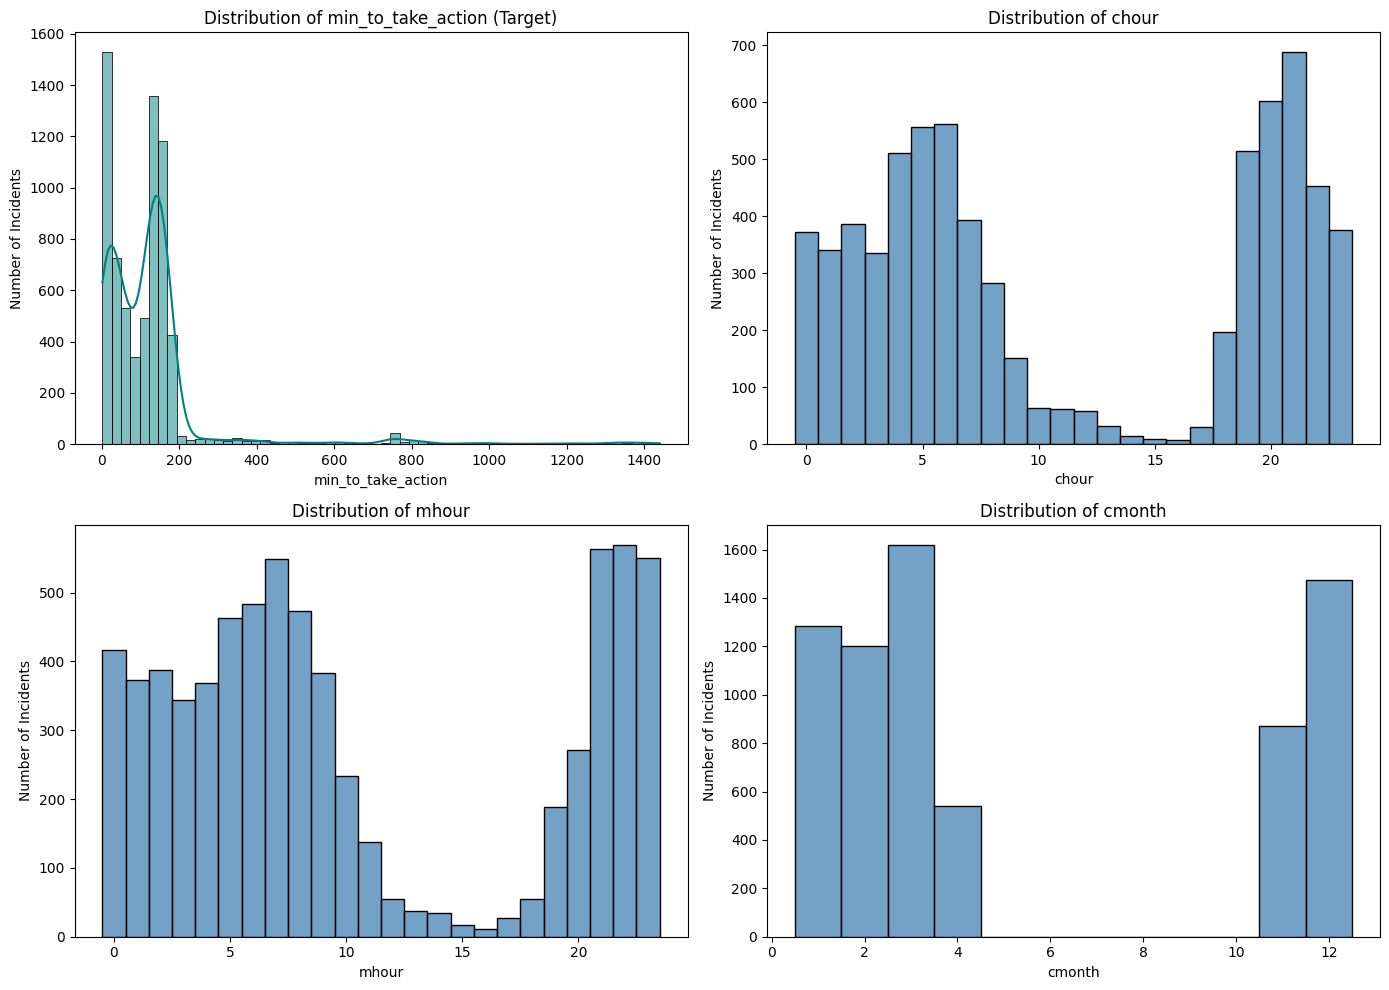

/tmp/ipykernel_2641/2994808490.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_pure, x=col, ax=axes[i], palette='viridis', order=order)
/tmp/ipykernel_2641/2994808490.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_pure, x=col, ax=axes[i], palette='viridis', order=order)
/tmp/ipykernel_2641/2994808490.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_pure, x=col, ax=axes[i], palette='viridis', order=order)
/tmp/ipykernel_2641/2994808490.py:45: FutureWarning: 

Passing `palette` without assigning `hu

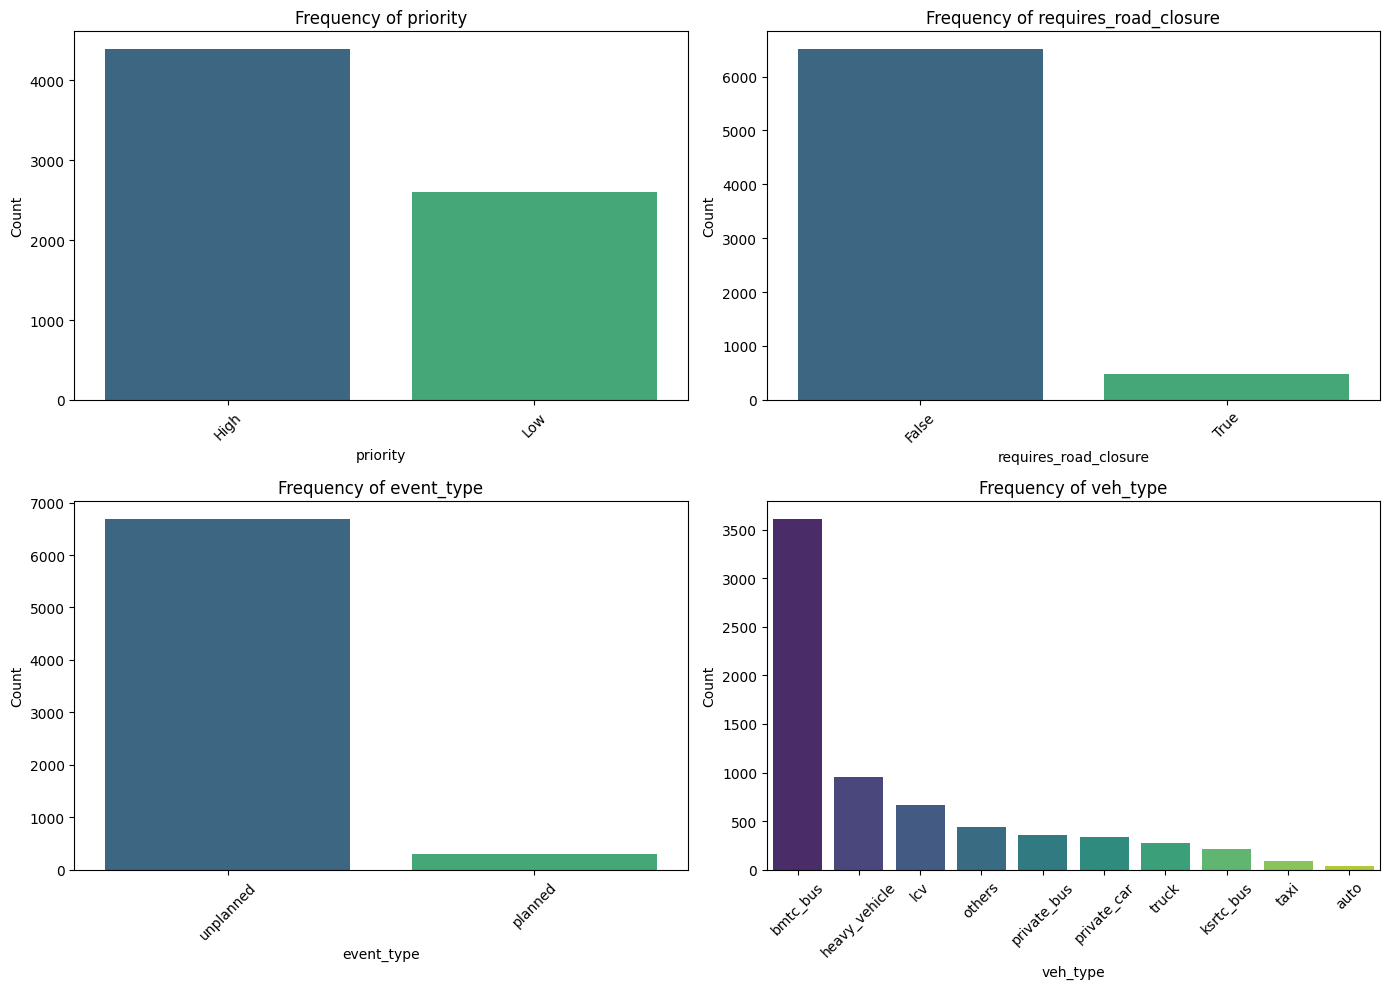

In [160]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. NUMERICAL HISTOGRAMS (Time & Target)
# ==========================================
# We focus on the most important numerical columns
num_cols = ['min_to_take_action', 'chour', 'mhour', 'cmonth']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    if col in df_pure.columns:
        # The target variable often needs more bins to see the fine details
        if col == 'min_to_take_action':
            sns.histplot(data=df_pure, x=col, bins=60, ax=axes[i], color='teal', kde=True)
            axes[i].set_title(f"Distribution of {col} (Target)", fontsize=12)
            # Optional: If the tail is extremely long, uncomment the next line to zoom in on the bulk of the data
            # axes[i].set_xlim(0, 300)
        else:
            # For hours (24 bins) and months (12 bins), we use discrete bins
            bins = 24 if 'hour' in col else 12
            sns.histplot(data=df_pure, x=col, bins=bins, ax=axes[i], color='steelblue', discrete=True)
            axes[i].set_title(f"Distribution of {col}", fontsize=12)

        axes[i].set_ylabel("Number of Incidents")

plt.tight_layout()
plt.show()

# ==========================================
# 2. CATEGORICAL "HISTOGRAMS" (Count Plots)
# ==========================================
# Let's check the volume of our other target and key features
cat_cols = ['priority', 'requires_road_closure', 'event_type', 'veh_type']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if col in df_pure.columns:
        # Order by highest frequency first
        order = df_pure[col].value_counts().index
        sns.countplot(data=df_pure, x=col, ax=axes[i], palette='viridis', order=order)
        axes[i].set_title(f"Frequency of {col}", fontsize=12)
        axes[i].set_ylabel("Count")
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [161]:
df_pure.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6993 entries, 0 to 8172
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   event_type             6993 non-null   object 
 1   latitude               6993 non-null   float64
 2   longitude              6993 non-null   float64
 3   event_cause            6993 non-null   object 
 4   requires_road_closure  6993 non-null   bool   
 5   status                 6993 non-null   object 
 6   authenticated          6993 non-null   object 
 7   veh_type               6993 non-null   object 
 8   corridor               6993 non-null   object 
 9   priority               6993 non-null   object 
 10  police_station         6993 non-null   object 
 11  add1                   6993 non-null   object 
 12  add2                   6993 non-null   object 
 13  pin                    6993 non-null   object 
 14  cmonth                 6993 non-null   int64  
 15  cdate    

In [162]:
# The final 7 columns that must go
columns_to_drop = [
    'status', 'authenticated', 'ctime', 'mtime',
    'mmonth', 'mdate', 'mhour'
]

# Create the final machine learning dataset
df_ml = df_pure.drop(columns=[c for c in columns_to_drop if c in df_pure.columns], errors='ignore')

# Verify we have exactly 16 columns left (14 features + 2 targets)
print(f"Final columns remaining: {len(df_ml.columns)}")

Final columns remaining: 16


In [163]:
from sklearn.cluster import KMeans
import pandas as pd # Import pandas for to_datetime

# Day of week
# Reconstruct a temporary datetime series from cmonth, cdate, chour to get day_of_week
# Assuming all events are in 2024 for day of week calculation as per previous steps.
df_ml_temp_created_dt = pd.to_datetime(
    '2024-' + df_ml['cmonth'].astype(str) + '-' + df_ml['cdate'].astype(str) +
    ' ' + df_ml['chour'].astype(str) + ':00:00', errors='coerce'
)
df_ml["day_of_week"] = df_ml_temp_created_dt.dt.dayofweek

# Weekend
df_ml["is_weekend"] = (
    df_ml["day_of_week"] >= 5
).astype(int)

# Rush hour
df_ml["rush_hour"] = (
    ((df_ml["chour"] >= 8) & (df_ml["chour"] <= 11))
    |
    ((df_ml["chour"] >= 17) & (df_ml["chour"] <= 20))
).astype(int)

# Location cluster
kmeans = KMeans(
    n_clusters=20,
    random_state=42,
    n_init=10
)

df_ml["location_cluster"] = kmeans.fit_predict(
    df_ml[["latitude", "longitude"]]
)


In [164]:
print(df_ml.columns.tolist())

['event_type', 'latitude', 'longitude', 'event_cause', 'requires_road_closure', 'veh_type', 'corridor', 'priority', 'police_station', 'add1', 'add2', 'pin', 'cmonth', 'cdate', 'chour', 'min_to_take_action', 'day_of_week', 'is_weekend', 'rush_hour', 'location_cluster']


In [165]:
X = df_ml.drop(
    columns=[
        'min_to_take_action',
        'requires_road_closure'
    ]
)

print(X.shape)
print(X.columns.tolist())

(6993, 18)
['event_type', 'latitude', 'longitude', 'event_cause', 'veh_type', 'corridor', 'priority', 'police_station', 'add1', 'add2', 'pin', 'cmonth', 'cdate', 'chour', 'day_of_week', 'is_weekend', 'rush_hour', 'location_cluster']


In [166]:
drop_cols = ["add1", "add2"]

# Removed 'is_delayed' as it is created later in the notebook
X = df_ml.drop(
    columns=[
        "min_to_take_action",
        "requires_road_closure",
        *drop_cols
    ]
)
print("Columns dropped successfully. Current shape:", X.shape)

Columns dropped successfully. Current shape: (6993, 16)


In [167]:
df_ml

,event_type,latitude,longitude,event_cause,requires_road_closure,veh_type,corridor,priority,police_station,add1,add2,pin,cmonth,cdate,chour,min_to_take_action,day_of_week,is_weekend,rush_hour,location_cluster
0,unplanned,13.040004,77.518099,vehicle_breakdown,False,lcv,Tumkur Road,High,Peenya,Jalahalli Cross Junction,Peenya,560058,3,7,17,152.0,3,0,1,16
1,unplanned,12.921876,77.645158,vehicle_breakdown,False,heavy_vehicle,ORR East 1,High,HSR Layout,Heavie Halcyon,Agara,560102,1,30,4,9.0,1,0,0,19
4,unplanned,12.953980,77.585233,vehicle_breakdown,False,private_bus,Non-corridor,Low,Wilson Garden,Lalbagh Main Gate Junction,Wilson Garden,560027,1,30,4,37.0,1,0,0,1
5,unplanned,13.066485,77.599875,accident,False,bmtc_bus,Non-corridor,Low,Hebbala,Amrutahalli,Amruthahalli,Unknown,11,28,3,87.0,3,0,0,0
6,unplanned,12.932870,77.487981,vehicle_breakdown,False,bmtc_bus,Non-corridor,Low,Kengeri,Ambedkar Circle,Kengeri Satellite Town,560060,1,30,7,127.0,1,0,0,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8168,unplanned,12.917775,77.600024,vehicle_breakdown,False,lcv,Bannerghata Road,High,Mico Layout,Jayadeva Junction,BTM Layout Stage 1,560029,1,29,21,20.0,0,0,0,2
8169,unplanned,12.890951,77.564757,vehicle_breakdown,False,bmtc_bus,Non-corridor,Low,K.S. Layout,Century Central,Naidu Layout,560062,1,29,21,9.0,0,0,0,2
8170,unplanned,12.916976,77.583443,vehicle_breakdown,False,bmtc_bus,Non-corridor,Low,Jayanagara,Adarsh Palace Apartment,TMC Layout,560078,1,29,21,13.0,0,0,0,2
8171,unplanned,12.972042,77.619483,pot_holes,False,bmtc_bus,Old Madras Road,High,Halasur,Trinity Circle,Ashok Nagar,560001,1,29,22,2.0,0,0,0,1


In [168]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# ==========================================
# 1. THE NEW TARGET: SLA BREACH (OVER 60 MINS)
# ==========================================
# If it takes more than 60 mins, it's a 1 (Delayed). Otherwise, 0 (On Time).
df_ml['is_delayed'] = (df_ml['min_to_take_action'] > 60).astype(int)

# Drop the old targets completely
X = df_ml.drop(columns=['min_to_take_action', 'requires_road_closure', 'is_delayed'])
y = df_ml['is_delayed']

# ==========================================
# 2. THE FRESH ARCHITECTURE PIPELINE
# ==========================================
# Define categorical columns
cat_cols = [
    'event_type', 'event_cause', 'veh_type', 'corridor',
    'priority', 'police_station', 'add1', 'add2', 'pin'
]

# Ensure they are strings
for col in cat_cols:
    X[col] = X[col].fillna("Unknown").astype(str)

# We use an OrdinalEncoder to translate text into numbers for the new model
categorical_transformer = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

preprocessor = ColumnTransformer(
    transformers=[('cat', categorical_transformer, cat_cols)],
    remainder='passthrough' # Leave numbers (like chour, cmonth) alone
)

# Initialize the new Gradient Boosting Engine
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(
        max_iter=500,
        learning_rate=0.05,
        max_depth=5,
        class_weight='balanced', # Automatically handles the ratio of fast vs slow tickets
        random_state=42
    ))
])

# ==========================================
# 3. TRAIN AND EVALUATE
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("🚀 Training SLA Breach Predictor...\n")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("="*50)
print("🏆 NEW MODEL: DELAY RISK PERFORMANCE")
print("="*50)
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['On Time (<60m)', 'Delayed (>60m)']))

🚀 Training SLA Breach Predictor...

🏆 NEW MODEL: DELAY RISK PERFORMANCE
Overall Accuracy: 69.98%

Classification Report:
                precision    recall  f1-score   support

On Time (<60m)       0.60      0.56      0.58       520
Delayed (>60m)       0.75      0.78      0.77       879

      accuracy                           0.70      1399
     macro avg       0.68      0.67      0.67      1399
  weighted avg       0.70      0.70      0.70      1399



In [169]:

# ===== Feature Engineering Improvements =====
from sklearn.cluster import KMeans

# Temporal features
# Reconstruct a temporary datetime series from cmonth, cdate, chour to get day_of_week
# Assuming all events are in 2024 for day of week calculation as per previous steps.
df_ml_temp_created_dt = pd.to_datetime(
    '2024-' + df_ml['cmonth'].astype(str) + '-' + df_ml['cdate'].astype(str) +
    ' ' + df_ml['chour'].astype(str) + ':00:00', errors='coerce'
)
df_ml["day_of_week"] = df_ml_temp_created_dt.dt.dayofweek
df_ml["is_weekend"] = (df_ml["day_of_week"] >= 5).astype(int)

df_ml["rush_hour"] = (
    ((df_ml["chour"] >= 8) & (df_ml["chour"] <= 11)) |
    ((df_ml["chour"] >= 17) & (df_ml["chour"] <= 20))
).astype(int)

# Location clustering
kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
df_ml["location_cluster"] = kmeans.fit_predict(
    df_ml[["latitude", "longitude"]]
)

print("New features created successfully")


New features created successfully


In [170]:

# ===== Model Evaluation =====
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

preds = model.predict(X_test)

if hasattr(model, "predict_proba"):
    probs = model.predict_proba(X_test)[:, 1]
    print("ROC-AUC:", roc_auc_score(y_test, probs))

print("Accuracy :", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall   :", recall_score(y_test, preds))
print("F1 Score :", f1_score(y_test, preds))
print("Confusion Matrix")
print(confusion_matrix(y_test, preds))


ROC-AUC: 0.752740220530323
Accuracy : 0.6997855611150822
Precision: 0.7508196721311475
Recall   : 0.7815699658703071
F1 Score : 0.7658862876254181
Confusion Matrix
[[292 228]
 [192 687]]


In [ ]:

# ===== CatBoost Version (Try for higher AUC) =====
!pip install -q catboost

from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

cat_model = CatBoostClassifier(
    iterations=1500,
    depth=8,
    learning_rate=0.03,
    eval_metric='AUC',
    auto_class_weights='Balanced',
    verbose=100,
    random_state=42
)

cat_model.fit(X_train, y_train)

preds = cat_model.predict(X_test)
probs = cat_model.predict_proba(X_test)[:,1]

print("=== CATBOOST RESULTS ===")
print("ROC-AUC  :", roc_auc_score(y_test, probs))
print("Accuracy :", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall   :", recall_score(y_test, preds))
print("F1 Score :", f1_score(y_test, preds))
